In [1]:
# Open count stores and run Scarf analyses.
import scarf
# Select explicit fields and display options for plots.
from scarf.plotting import CellField, ColorScale, FeatureRef

# Keep routine logs and progress bars out of the results.
scarf.configure_output(level="WARNING", progress=False)

# Download the prepared example store.
dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
# Open the count store for this analysis.
ds = scarf.DataStore(f"{dataset}/data.zarr", nthreads=4)
# Open the saved analysis and its exact results.
run = ds.pipeline.open(label="docs_default")
# Keep the graph from the saved analysis.
graph = run["connectivity_map"]
# Inspect the opened store's cells and features.
ds

DataStore has 3948 (5025) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_G2M_score', 'RNA_S_score', 
            'RNA_UMAP1', 'RNA_UMAP2', 'RNA_cell_cycle_phase', 'RNA_clusters', 'RNA_doublet_score', 
            'RNA_leiden_cluster', 'RNA_nCounts', 'RNA_nFeatures', 'RNA_paris_cluster', 'RNA_percentMito', 
            'RNA_percentRibo'
   RNA assay has 33538 features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'feature_type', 
            'genome', 'nCells'

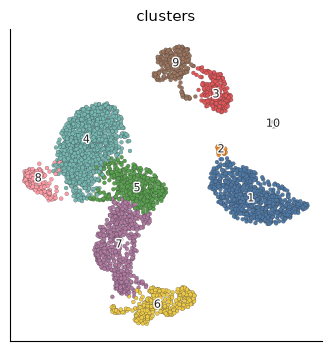

In [2]:
# Locate the PBMC clusters before comparing CD4 expression.
ds.plots.embedding(run=run, layout="umap", color_by="clusters", legend_loc="on_data")

In [3]:
# Build the diffusion operator with the default two steps.
diffusion = ds.run_diffusion_operator(graph)
# Apply diffusion to normalized CD4 expression.
smoothed = ds.get_imputed(feature_name="CD4", diffusion=diffusion)
# Save the calculated values in the cell table.
ds.cells.insert("CD4_imputed_t2", smoothed, key="I", overwrite=True)
# Check the number of smoothed cells and their expression range.
{
    "cells": len(smoothed),
    "minimum": round(float(smoothed.min()), 4),
    "maximum": round(float(smoothed.max()), 4),
}

{'cells': 3948, 'minimum': 0.0, 'maximum': 0.3002}

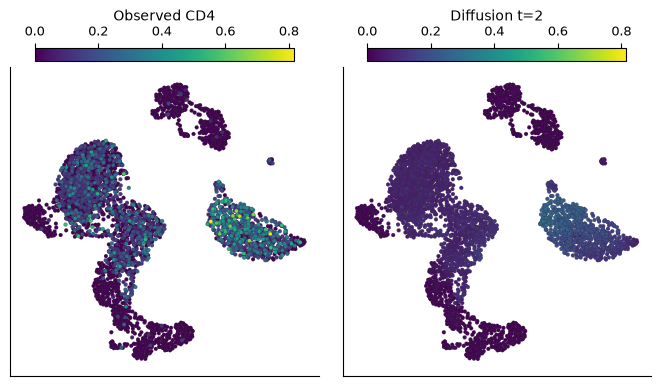

In [4]:
# Compare observed CD4 with two-step smoothing on a shared color scale.
ds.plots.embedding(
    layout=run["umap"],
    color_by=[
        FeatureRef("CD4", label="Observed CD4"),
        CellField("CD4_imputed_t2", kind="continuous", label="Diffusion t=2"),
    ],
    n_columns=2,
    color_scale=ColorScale(scope="shared"),
    sort_values=True,
)

In [5]:
# Compute the two additional diffusion depths.
for t in (1, 3):
    # Build the operator for this diffusion depth.
    operator = ds.run_diffusion_operator(graph, t=t)
    # Smooth CD4 expression with this operator.
    values = ds.get_imputed(feature_name="CD4", diffusion=operator)
    # Save the calculated values in the cell table.
    ds.cells.insert(f"CD4_imputed_t{t}", values, key="I", overwrite=True)

# Confirm which smoothing depths are ready to compare.
{"diffusion steps": [1, 2, 3], "cells per column": len(values)}

{'diffusion steps': [1, 2, 3], 'cells per column': 3948}

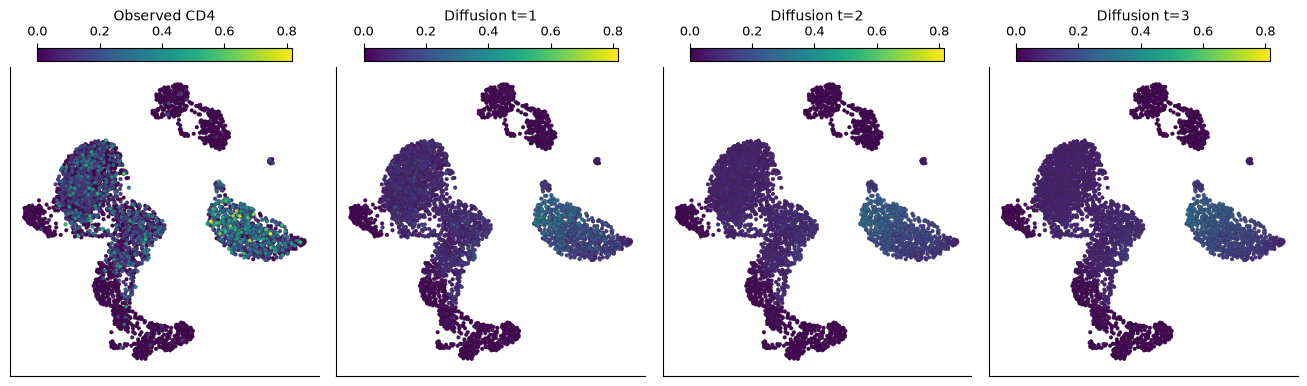

In [6]:
# Name the three smoothed columns for the comparison plot.
diffusion_fields = [
    CellField(f"CD4_imputed_t{t}", kind="continuous", label=f"Diffusion t={t}")
    for t in (1, 2, 3)
]
# Compare observed CD4 with all three diffusion depths.
ds.plots.embedding(
    layout=run["umap"],
    color_by=[FeatureRef("CD4", label="Observed CD4"), *diffusion_fields],
    n_columns=4,
    color_scale=ColorScale(scope="shared"),
    sort_values=True,
)